In [2]:
import pandas as pd
import numpy as np
import warnings
import gc

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
# Suppress warnings

warnings.filterwarnings("ignore")

# ---------------

In [9]:
iris = load_iris()  # Just to ensure sklearn is available and working --- IGNORE ---
data = iris.data
target = iris.target_names
df = pd.DataFrame(data, columns=iris.feature_names)
df['target'] = target[iris.target]  
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [15]:
# ------------------------------------------
# 1. LOAD DATA & SETUP
# ---------------------------------------------------------
print("Loading data...")

train = df.copy()

TARGET = "target"
target_mapping = {"setosa": 0, "versicolor": 1, "virginica": 2}
inverse_target_mapping = {0: "setosa", 1: "versicolor", 2: "virginica"}

train[TARGET] = train[TARGET].map(target_mapping)

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING
# ---------------------------------------------------------
print("Engineering features...")

def create_features(df):
    df = df.copy()

    # 4 boolean numeric features based on Iris dataset
    df["sepal_length_lt_6"] = (df["sepal length (cm)"] < 6).astype(int)
    df["sepal_width_gt_3"] = (df["sepal width (cm)"] > 3).astype(int)
    df["petal_length_lt_4"] = (df["petal length (cm)"] < 4).astype(int)
    df["petal_width_gt_1"] = (df["petal width (cm)"] > 1).astype(int)

    return df

train = create_features(train)

NUM_FEATURES = [
    "sepal_length_lt_6",
    "sepal_width_gt_3",
    "petal_length_lt_4",
    "petal_width_gt_1",
]

CAT_FEATURES = []

# ---------------------------------------------------------
# 3. ONE-HOT ENCODE FEATURES
# ---------------------------------------------------------
print("Creating one-hot encoded features...")

X = pd.get_dummies(
    train[NUM_FEATURES + CAT_FEATURES],
    columns=CAT_FEATURES,
    drop_first=False
)

FEATURES = X.columns.tolist()
y = train[TARGET].copy()

print(f"Total engineered features: {len(FEATURES)}")
print("Features:")
for f in FEATURES:
    print(f"  {f}")

# ---------------------------------------------------------
# 4. TRAINING WITH 5-FOLD CV
# ---------------------------------------------------------
print("\nTraining Logistic Regression with 5-Fold CV...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg_oof = np.zeros((len(train), 3))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n{'=' * 40}\nFold {fold}/5\n{'=' * 40}")

    X_tr = X.iloc[train_idx].copy()
    y_tr = y.iloc[train_idx].copy()

    X_val = X.iloc[val_idx].copy()
    y_val = y.iloc[val_idx].copy()

    # Class-balanced sample weights
    classes = np.unique(y_tr)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
    class_weight_dict = dict(zip(classes, weights))
    sample_weights = np.array([class_weight_dict[label] for label in y_tr])

    # Model (only pass kwargs supported by the installed LogisticRegression)
    supported_params = LogisticRegression.__init__.__code__.co_varnames
    model_kwargs = {"max_iter": 1000}

    if "multi_class" in supported_params:
        model_kwargs["multi_class"] = "multinomial"
    if "solver" in supported_params:
        model_kwargs["solver"] = "lbfgs"
    if "random_state" in supported_params:
        model_kwargs["random_state"] = 42
    if "n_jobs" in supported_params:
        model_kwargs["n_jobs"] = -1

    model = LogisticRegression(**model_kwargs)

    # Train
    model.fit(X_tr, y_tr, sample_weight=sample_weights)

    # Predict
    val_pred_proba = model.predict_proba(X_val)
    logreg_oof[val_idx] = val_pred_proba

    # Fold metric
    val_pred = np.argmax(val_pred_proba, axis=1)
    fold_acc = balanced_accuracy_score(y_val, val_pred)
    fold_scores.append(fold_acc)
    print(f"Fold {fold} Balanced Accuracy: {fold_acc:.5f}")

    gc.collect()

# ---------------------------------------------------------
# 5. OVERALL METRICS
# ---------------------------------------------------------
oof_pred = np.argmax(logreg_oof, axis=1)

overall_acc = balanced_accuracy_score(train[TARGET], oof_pred)
print(f"\nOverall CV Balanced Accuracy: {overall_acc:.5f}")
print(f"Mean Fold Balanced Accuracy : {np.mean(fold_scores):.5f}")
print(f"Std Fold Balanced Accuracy  : {np.std(fold_scores):.5f}")

# Recall for each class
class_recalls = recall_score(
    train[TARGET],
    oof_pred,
    labels=[0, 1, 2],
    average=None
)

print("\nRecall by target class:")
for class_id, recall_val in zip([0, 1, 2], class_recalls):
    print(f"  {inverse_target_mapping[class_id]}: {recall_val:.5f}")

Loading data...
Engineering features...
Creating one-hot encoded features...
Total engineered features: 4
Features:
  sepal_length_lt_6
  sepal_width_gt_3
  petal_length_lt_4
  petal_width_gt_1

Training Logistic Regression with 5-Fold CV...

Fold 1/5
Fold 1 Balanced Accuracy: 0.80000

Fold 2/5
Fold 2 Balanced Accuracy: 0.70000

Fold 3/5
Fold 3 Balanced Accuracy: 0.80000

Fold 4/5
Fold 4 Balanced Accuracy: 0.83333

Fold 5/5
Fold 5 Balanced Accuracy: 0.63333

Overall CV Balanced Accuracy: 0.75333
Mean Fold Balanced Accuracy : 0.75333
Std Fold Balanced Accuracy  : 0.07483

Recall by target class:
  setosa: 1.00000
  versicolor: 0.40000
  virginica: 0.86000


In [16]:
classes = np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
class_weight_dict = dict(zip(classes, weights))
sample_weights = np.array([class_weight_dict[label] for label in y])

_ = model.fit(X, y, sample_weight=sample_weights)

print("\nLogistic Regression Formula:\n")

feature_names = FEATURES  # from your pipeline

coefs = model.coef_        # shape: (n_classes, n_features)
intercepts = model.intercept_

for class_idx in range(coefs.shape[0]):
    class_name = inverse_target_mapping[class_idx]

    print(f"\nClass: {class_name}")
    print("-" * 50)

    terms = []
    for coef, fname in zip(coefs[class_idx], feature_names):
        terms.append(f"({coef:.4f} * {fname})")

    equation = " + ".join(terms)

    print(f"logit(P(y={class_name})) = {intercepts[class_idx]:.4f} + {equation}")


Logistic Regression Formula:


Class: setosa
--------------------------------------------------
logit(P(y=setosa)) = -1.2910 + (0.9439 * sepal_length_lt_6) + (1.4297 * sepal_width_gt_3) + (1.5614 * petal_length_lt_4) + (-1.9248 * petal_width_gt_1)

Class: versicolor
--------------------------------------------------
logit(P(y=versicolor)) = 0.7468 + (0.1099 * sepal_length_lt_6) + (-0.9988 * sepal_width_gt_3) + (-0.2163 * petal_length_lt_4) + (0.6744 * petal_width_gt_1)

Class: virginica
--------------------------------------------------
logit(P(y=virginica)) = 0.5442 + (-1.0538 * sepal_length_lt_6) + (-0.4309 * sepal_width_gt_3) + (-1.3450 * petal_length_lt_4) + (1.2504 * petal_width_gt_1)


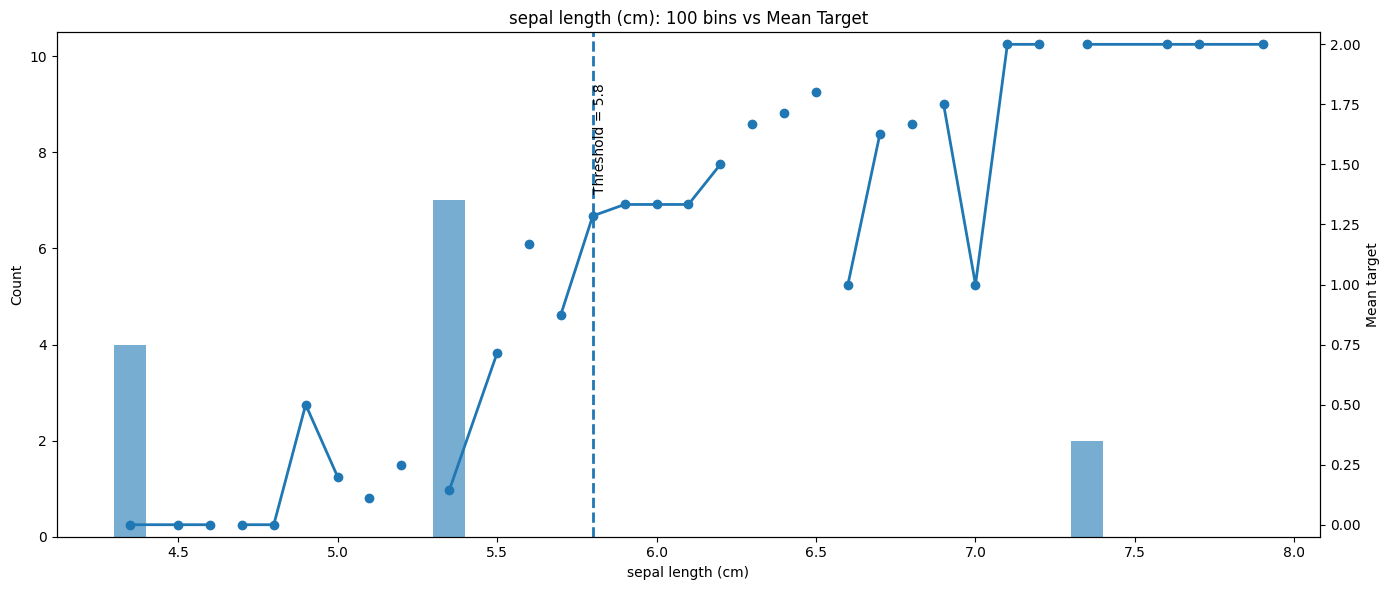

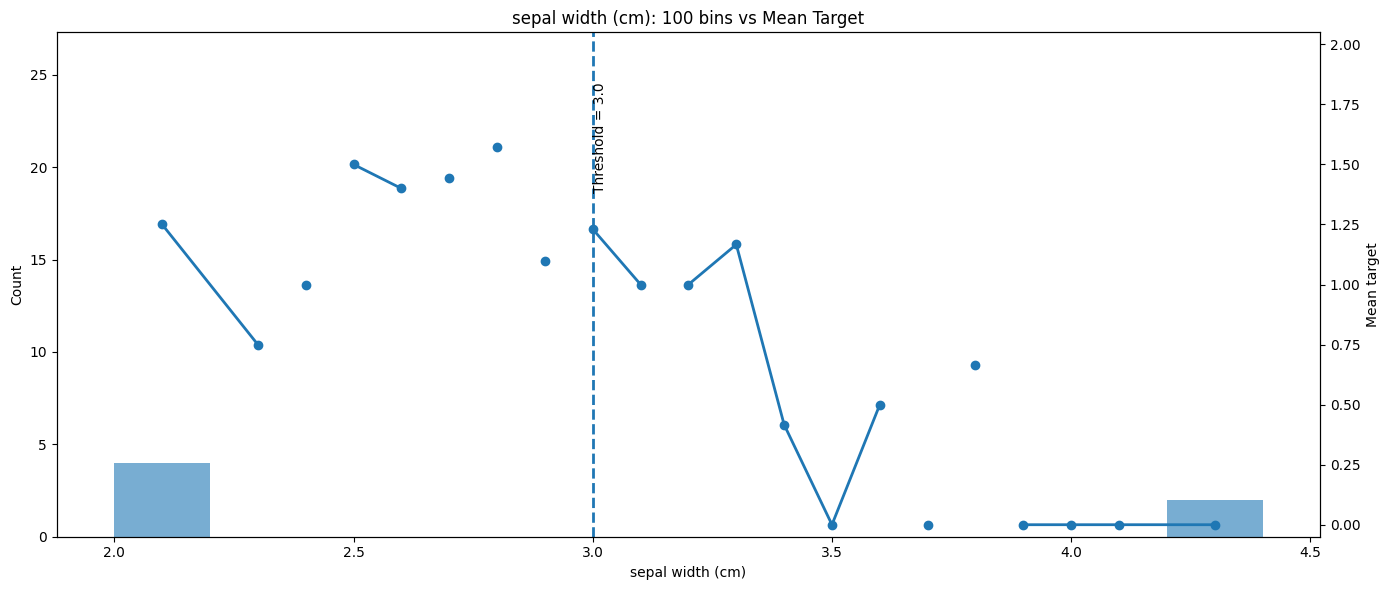

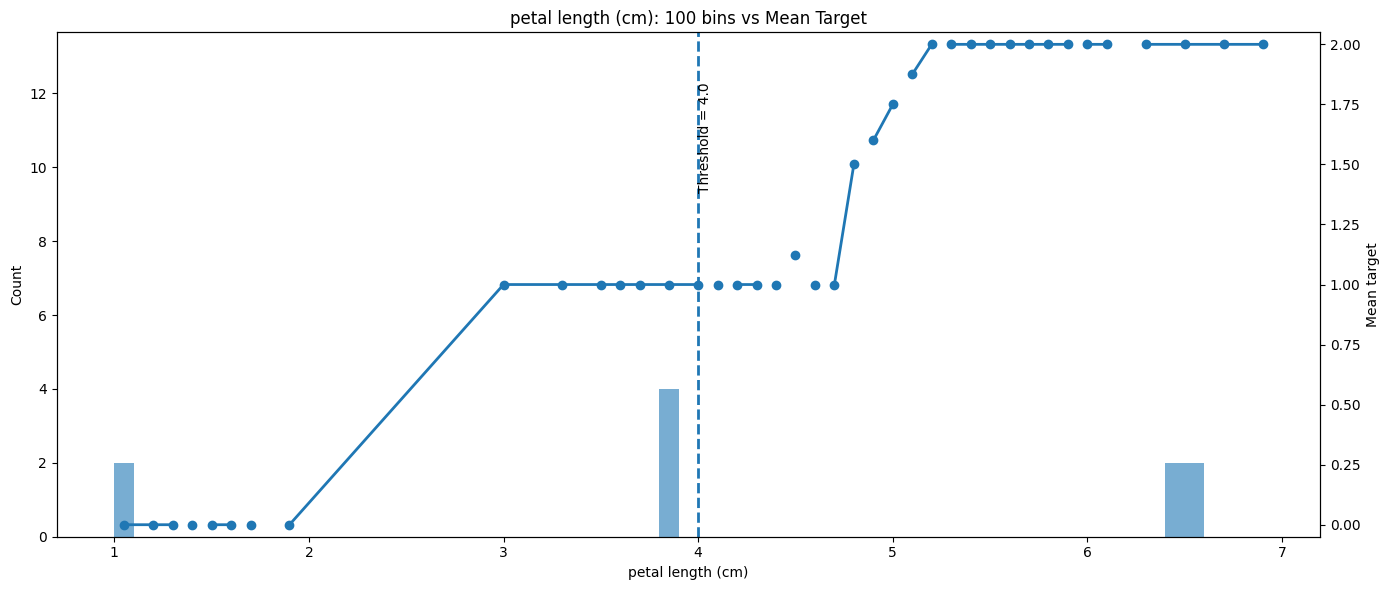

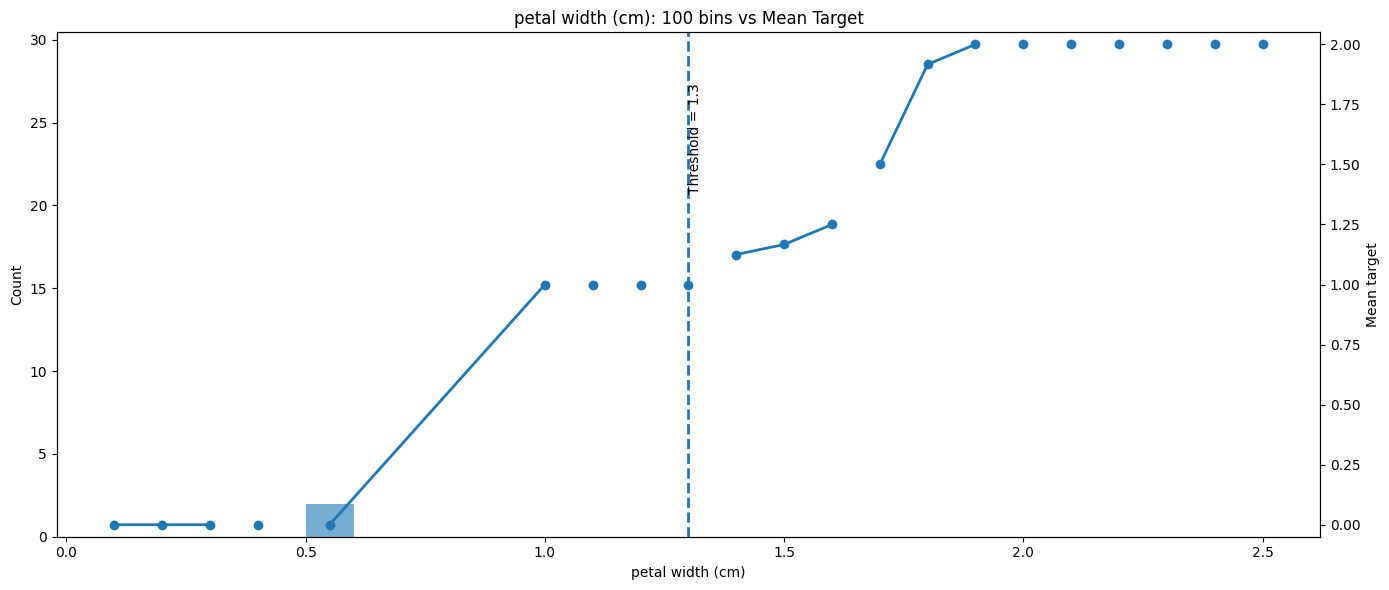

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------

if pd.api.types.is_numeric_dtype(train[TARGET]):
    train["target_num"] = train[TARGET].astype(int)
else:
    target_mapping = {"setosa": 0, "versicolor": 1, "virginica": 2}
    train["target_num"] = train[TARGET].map(target_mapping)

# ---------------------------------------------------------
# 2. DEFINE FEATURES + THRESHOLDS
# ---------------------------------------------------------
feature_config = {
    "sepal length (cm)": 5.8,
    "sepal width (cm)": 3.0,
    "petal length (cm)": 4.0,
    "petal width (cm)": 1.3,
}

n_bins = 100

# ---------------------------------------------------------
# 3. LOOP THROUGH FEATURES
# ---------------------------------------------------------
for col, threshold in feature_config.items():

    df = train.copy()

    # Quantile bins (more stable)
    df["bin"] = pd.qcut(df[col], q=n_bins, duplicates="drop")

    # Aggregate stats
    bin_stats = (
        df.groupby("bin", observed=False)
        .agg(
            count=(col, "size"),
            mean_target=("target_num", "mean"),
            bin_left=(col, "min"),
            bin_right=(col, "max"),
        )
        .reset_index()
    )

    bin_stats["bin_center"] = (bin_stats["bin_left"] + bin_stats["bin_right"]) / 2

    # ---------------------------------------------------------
    # PLOT
    # ---------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Bar plot (counts)
    ax1.bar(
        bin_stats["bin_center"],
        bin_stats["count"],
        width=(bin_stats["bin_right"] - bin_stats["bin_left"]).values,
        alpha=0.6,
        align="center"
    )
    ax1.set_xlabel(col)
    ax1.set_ylabel("Count")
    ax1.set_title(f"{col}: {n_bins} bins vs Mean Target")

    # Mean target line
    ax2 = ax1.twinx()
    ax2.plot(
        bin_stats["bin_center"],
        bin_stats["mean_target"],
        marker="o",
        linewidth=2
    )
    ax2.set_ylabel("Mean target")
    ax2.set_ylim(-0.05, 2.05)

    # ---------------------------------------------------------
    # THRESHOLD LINE
    # ---------------------------------------------------------
    ax1.axvline(
        x=threshold,
        linestyle="--",
        linewidth=2,
    )

    # Annotate threshold
    ax1.text(
        threshold,
        ax1.get_ylim()[1] * 0.9,
        f"Threshold = {threshold}",
        rotation=90,
        verticalalignment="top"
    )

    plt.tight_layout()
    plt.show()